### Cluster analysis with K-means

In [ ]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

In [2]:
dimensio = 2
t_span = (0, 40)
t_steps = 400
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
x_min, x_max = (-2, 2)
y_min, y_max = (-1, 1)
espai_entre_punts = 0.05
magnitud_soroll = espai_entre_punts / 100
max_clusters = 50

In [3]:
condicions_inicials = generar_condicions_inicials(
    espai_entre_punts, (x_min, x_max), (y_min, y_max)
)
num_trajectories = len(condicions_inicials)

Nombre de trajectòries = 3321 = 41 files * 81 columnes


In [4]:
trajectories = generar_trajectories(edo_duffing_no_autonom, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (3321, 400, 2)


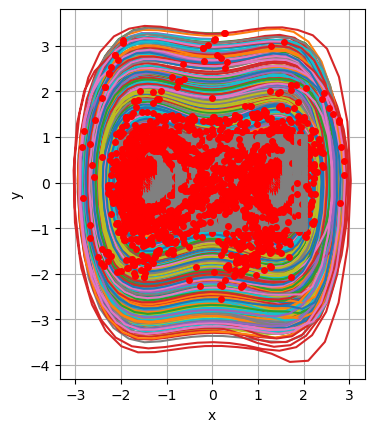

In [5]:
grafica_trajectories(trajectories, subfolder="no_autonom")

In [6]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [7]:
pes_max = np.max(matriu_pesos)
print(f"Pes màxim a la matriu de pesos: {pes_max:.3f}")
constant_diagonal = pes_max * 1e7

Pes màxim a la matriu de pesos: 74.858


##### Opció A: Usem el mateix radi d'esparsificació que Irina, és a dir, r = 1.0

In [8]:
sparsification_tol = 1.0
matriu_similaritat_W, sparsification_percent = sparcify_with_tol(matriu_pesos, tol=sparsification_tol)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{sparsification_tol:.3f}")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
print(matriu_similaritat_W)

S'ha obtingut una esparsificació del 89% usant una tolerància de 1.000
[[7.486e+08 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 7.486e+08 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 7.486e+08 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 7.486e+08 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 7.486e+08 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 7.486e+08]]


Descomposició espectral: $Lu =\lambda Du$, on la matriu diagonal de graus $D$ és $D_{ii}=\sum _{j=0}^{n} w_{ij}$.

In [9]:
vaps, veps = calcula_vaps(matriu_similaritat_W, max_clusters)
print("vaps =", vaps)
print("veps.shape =", veps.shape)

vaps = [-0. -0. -0. -0. -0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
veps.shape = (3321, 50)


In [10]:
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)

In [11]:
labels = troba_clusters(num_clusters, veps)

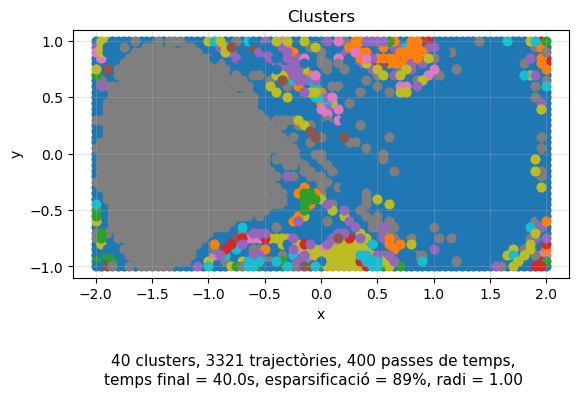

In [12]:
grafica_clusters(condicions_inicials, labels, num_clusters, sparsification_tol, 
                 sparsification_percent, t_steps, t_span, subfolder="no_autonom")

##### Opció B: triar radi d'esparsificació que maximitza la diferència màxima entre VAPs consecutius

Iniciant l'escombrat de paràmetres...
Radi òptim trobat: r=3.000 | k=1 clústers | W is 0.34% sparsified


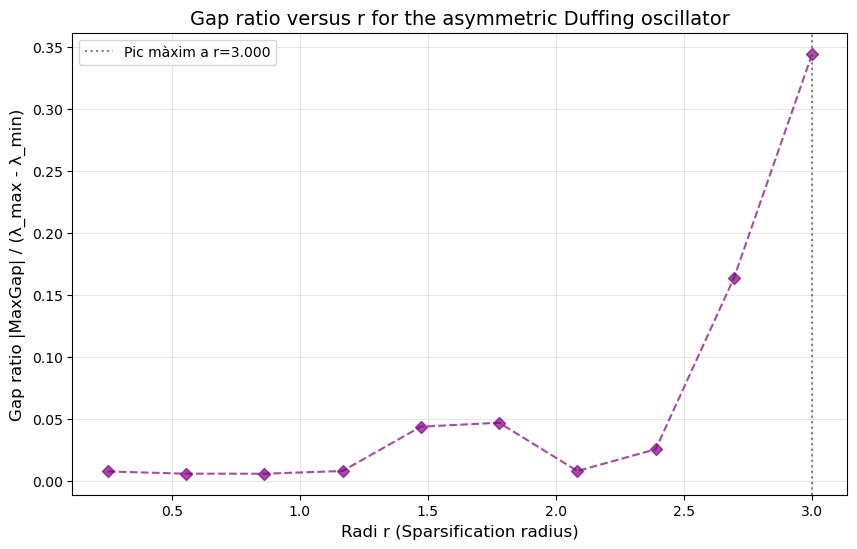

In [13]:
optimal_r, optimal_k, sparsification_percent = troba_radi_optim(trajectories)

In [14]:
labels = aplica_spectral_clustering_optim(trajectories, optimal_r, optimal_k)

Aplicant K-Means demanant exactament 1 clústers...


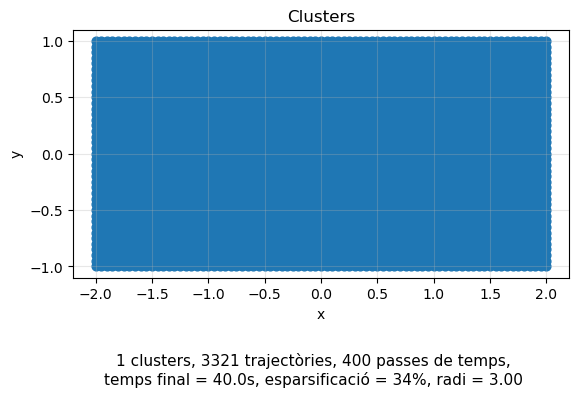

In [15]:
grafica_clusters(
    condicions_inicials, 
    labels, 
    optimal_k, 
    optimal_r,  
    sparsification_percent, 
    t_steps, 
    t_span, 
    subfolder="no_autonom"
)